# HW5: Exploratory Data Analysis of Heart Failure Dataset

This report is an exploratory data analysis (EDA) of the Kaggle heart failure dataset.

**Goal of the analysis:** to understand the data structure, identify key factors influencing heart disease risk, and prepare the data for further modeling.

**Audience:** This report is intended for people without a medical background, so all terms will be briefly explained.

### 1.1 Research Objective

This exploratory data analysis (EDA) aims to investigate the Heart Failure Clinical Records dataset to identify key factors associated with the presence of heart disease. The primary objectives are:

1. To assess data quality, including missing values, duplicates, and data type consistency.
2. To characterize the distribution of individual features (univariate analysis).
3. To examine relationships between predictor variables and the target variable `HeartDisease` (bivariate analysis).
4. To evaluate linear associations among numerical features via correlation analysis.
5. To detect potential outliers that may influence subsequent modeling.
6. To formulate recommendations for feature engineering and preprocessing prior to predictive modeling.

The insights gained from this analysis will inform the development of a robust classification model for heart disease prediction.

In [53]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn import datasets, decomposition

sns.set(style="whitegrid")
pd.set_option('display.max_columns', 100)

df = pd.read_csv('heart.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [54]:
target = 'HeartDisease'

### 2.1 Dataset Overview

The dataset comprises 918 patient records with 12 variables, including one binary target variable (`HeartDisease`). The features encompass demographic, clinical, and diagnostic measurements:

| Variable | Type | Description |
|----------|------|-------------|
| `Age` | Numerical | Patient age in years |
| `Sex` | Categorical | Gender (M/F) |
| `ChestPainType` | Categorical | Type of chest pain (ATA, NAP, ASY, TA) |
| `RestingBP` | Numerical | Resting blood pressure (mmHg) |
| `Cholesterol` | Numerical | Serum cholesterol (mg/dl) |
| `FastingBS` | Binary | Fasting blood sugar >120 mg/dl (1=Yes, 0=No) |
| `RestingECG` | Categorical | Resting electrocardiogram results |
| `MaxHR` | Numerical | Maximum heart rate achieved |
| `ExerciseAngina` | Binary | Exercise-induced angina (Y/N) |
| `Oldpeak` | Numerical | ST depression induced by exercise relative to rest |
| `ST_Slope` | Categorical | Slope of the peak exercise ST segment |
| `HeartDisease` | Binary (Target) | Presence of heart disease (1=Yes, 0=No) |



## Dataset Overview

In [55]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


### 2.2 Data Types and Structure

- **Numerical features**: 6 variables (`Age`, `RestingBP`, `Cholesterol`, `FastingBS`, `MaxHR`, `Oldpeak`)
- **Categorical features**: 5 variables (`Sex`, `ChestPainType`, `RestingECG`, `ExerciseAngina`, `ST_Slope`)
- **Target variable**: Binary (`HeartDisease`)

No duplicate records were detected (`df.duplicated().sum() = 0`), confirming data uniqueness at the record level.



## 3.1 Missing Values

Initial inspection revealed no explicit `NaN` values. However, domain knowledge suggests that zero values in `RestingBP` and `Cholesterol` likely represent missing measurements rather than physiological zeros. Accordingly, these values were recoded as missing for subsequent analysis:

```python
for col in ['RestingBP', 'Cholesterol']:
    df_eda.loc[df_eda[col] == 0, col] = np.nan

In [56]:
df_eda = df.copy()

for col in ['RestingBP', 'Cholesterol']:
    if col in df_eda.columns:
        df_eda.loc[df_eda[col] == 0, col] = np.nan

print("\nMissing values:\n", df_eda.isna().sum().sort_values(ascending=False))


Missing values:
 Cholesterol       172
RestingBP           1
Sex                 0
Age                 0
ChestPainType       0
FastingBS           0
RestingECG          0
MaxHR               0
ExerciseAngina      0
Oldpeak             0
ST_Slope            0
HeartDisease        0
dtype: int64


## 4. Univariate Analysis
### 4.1 Numerical Features

Distributional characteristics of numerical variables were assessed via histograms with kernel density estimates:

- **`Age`**: Approximately symmetric distribution centered around 53–54 years; suitable for parametric methods.
- **`MaxHR`**: Near-symmetric distribution with moderate spread; no extreme skewness observed.
- **`RestingBP`**: Unimodal with slight right skew; values cluster around 120–140 mmHg.
- **`Cholesterol`**: Pronounced right skew with a long tail of high values; log-transformation may improve normality.
- **`Oldpeak`**: Strong right skew with many zero values and occasional high outliers; consider transformation or binning.
- **`FastingBS`**: Binary distribution heavily weighted toward 0 (≈77%); treated as categorical in subsequent analyses.

### 4.2 Categorical Features

Frequency analysis of categorical variables revealed:

- `Sex`: Moderate imbalance (≈65% male, 35% female).
- `ChestPainType`: Four distinct categories with varying frequencies; `ASY` (asymptomatic) is most prevalent.
- `RestingECG`: Three categories; `Normal` and `ST` dominate.
- `ExerciseAngina`: Binary; "N" (No) is predominant.
- `ST_Slope`: Three categories; `Up` and `Flat` are most common.

No categorical variable exhibits extreme sparsity that would necessitate category consolidation at this stage.

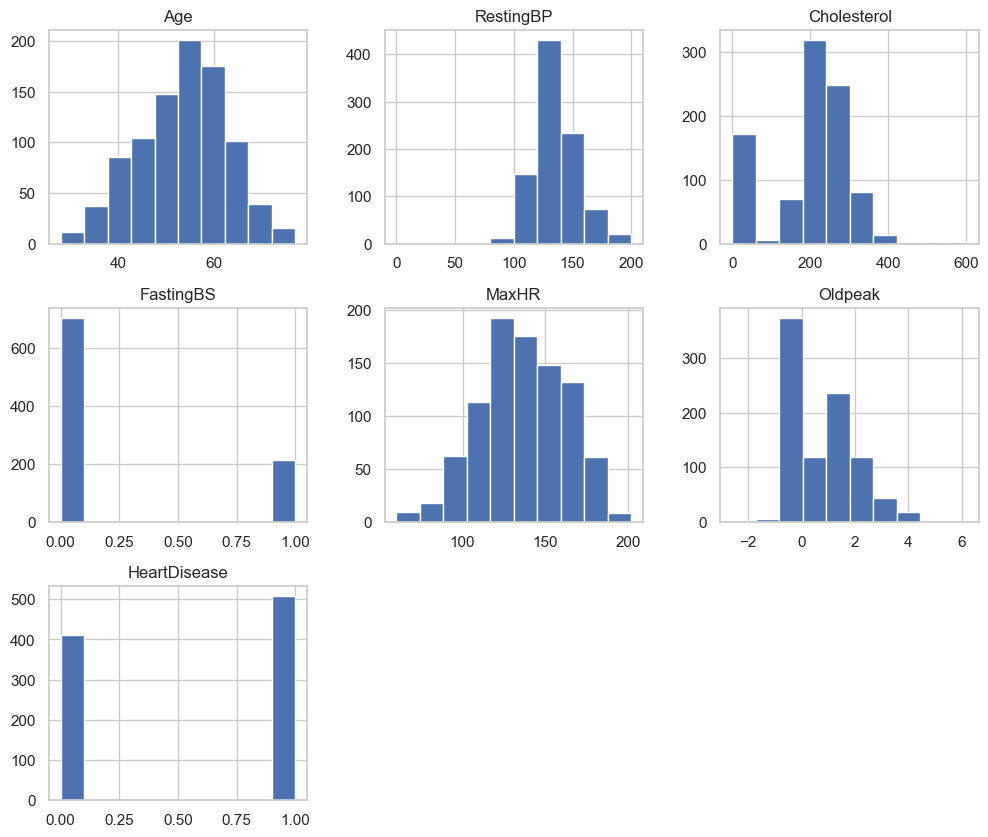

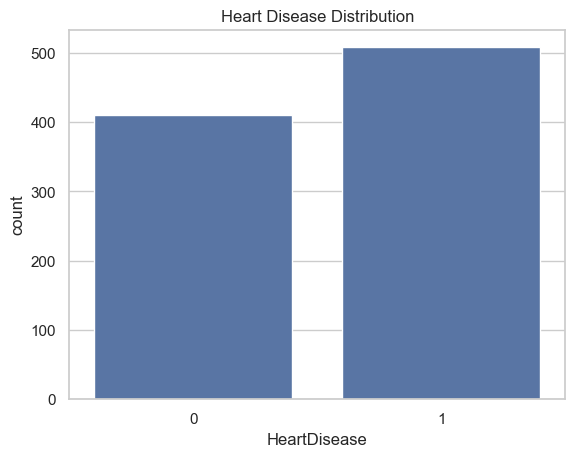

In [57]:
df.hist(figsize=(12,10))
plt.show()

sns.countplot(x=target, data=df)
plt.title('Heart Disease Distribution')
plt.show()

Observations:
- Age: approximately normal distribution, centered around 53-54 years
- Cholesterol: right-skewed with some extreme values
- MaxHR: roughly normal, centered around 137 bpm
- Oldpeak: heavily right-skewed, most values near 0
- Target: relatively balanced (55% positive cases)

## 5.1 Numerical Features vs. Target

Boxplot visualizations and statistical comparisons reveal the following associations with `HeartDisease`:

| Feature | Direction of Association | Strength | Notes |
|---------|-------------------------|----------|-------|
| `Age` | Positive | Moderate | Higher age associated with increased disease prevalence |
| `MaxHR` | Negative | Strong | Lower maximum heart rate strongly associated with disease |
| `Oldpeak` | Positive | Strong | Higher ST depression strongly predictive of disease |
| `RestingBP` | Weak | Low | Substantial overlap between classes |
| `Cholesterol` | Weak | Low | High variance obscures clear class separation |
| `FastingBS` | Positive | Moderate | Elevated fasting blood sugar associated with disease |

### 5.2 Categorical Features vs. Target

Stacked bar plots of conditional proportions indicate:

- **`ChestPainType`**: Patients with `ASY` (asymptomatic) chest pain exhibit the highest proportion of heart disease (>70%), whereas `TA` (typical angina) is associated with the lowest risk.
- **`ExerciseAngina`**: Presence of exercise-induced angina (`Y`) corresponds to a markedly higher disease rate (~80% vs. ~35% for `N`).
- **`ST_Slope`**: `Flat` and `Down` slopes are strongly associated with heart disease compared to `Up`.
- **`Sex`**: Male patients show a higher prevalence of heart disease than females.
- **`RestingECG`**: Modest association; `ST` abnormalities correlate with increased disease likelihood.

These findings suggest that `ChestPainType`, `ExerciseAngina`, and `ST_Slope` are promising candidates for inclusion in predictive models.

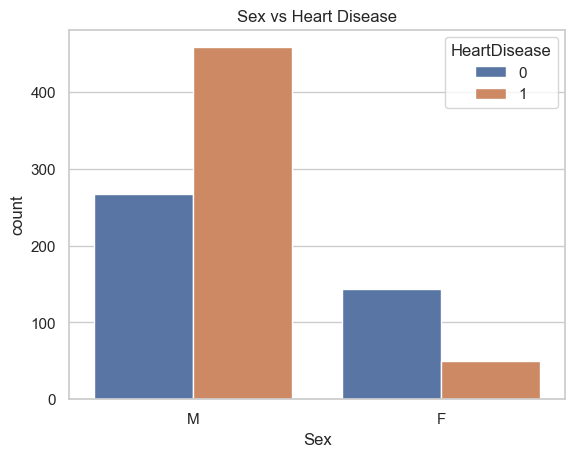

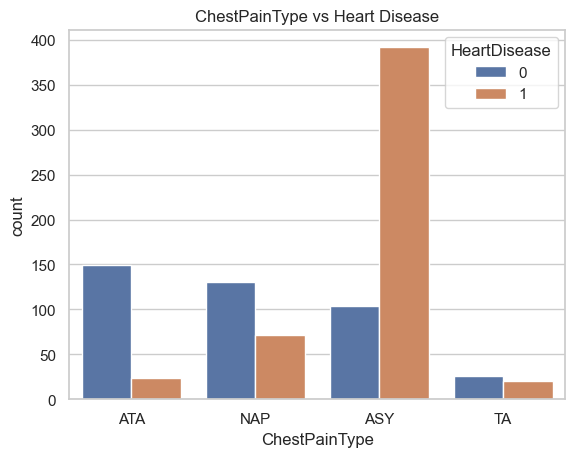

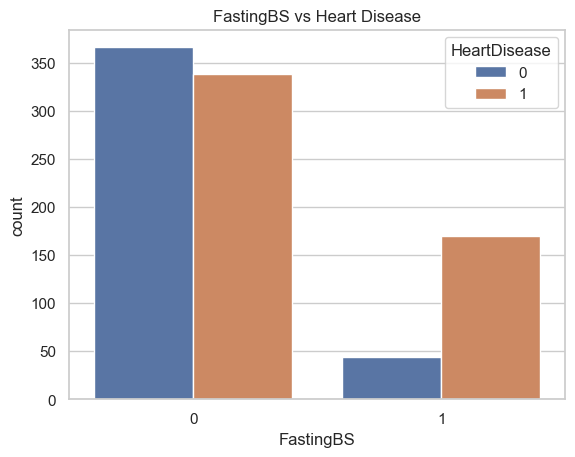

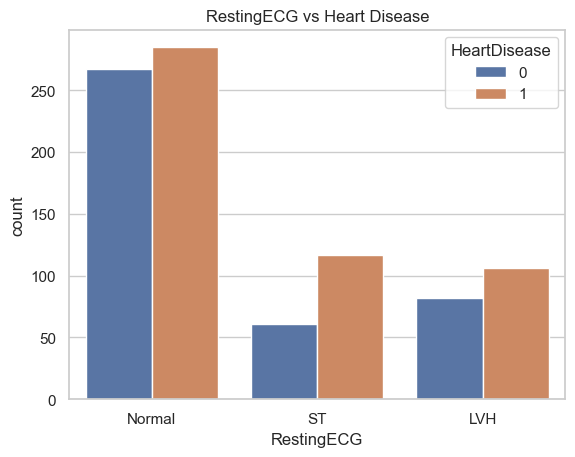

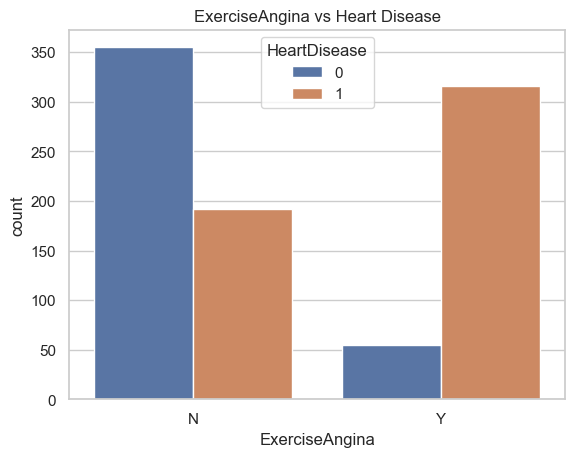

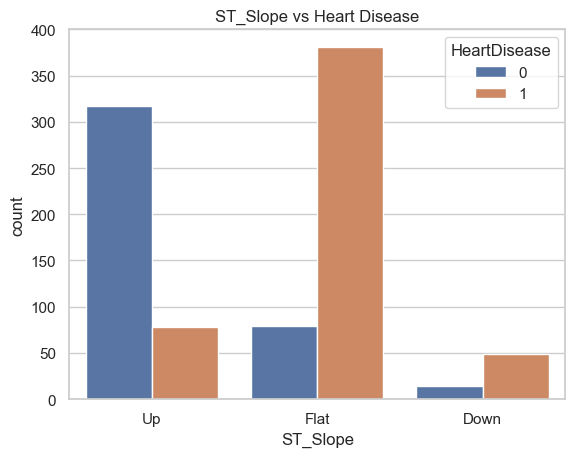

In [58]:
categorical = ["Sex", "ChestPainType", "FastingBS", "RestingECG", "ExerciseAngina", "ST_Slope"]

for col in categorical:
    sns.countplot(x=col, hue=target, data=df)
    plt.title(f"{col} vs Heart Disease")
    plt.show()

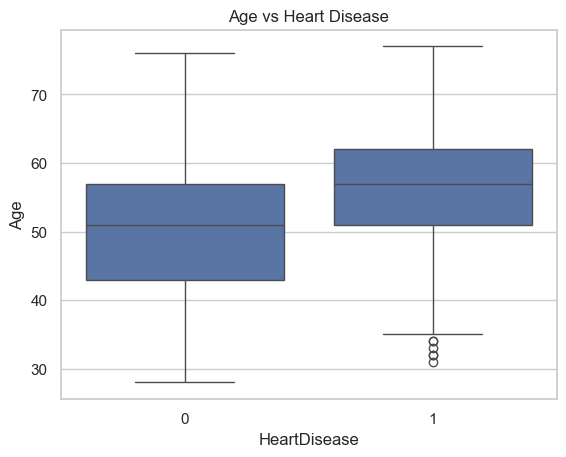

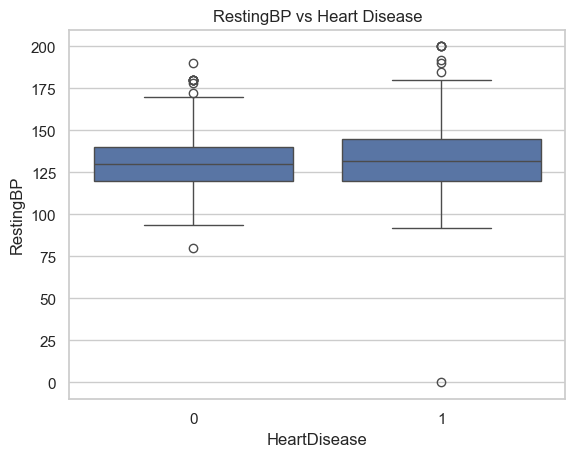

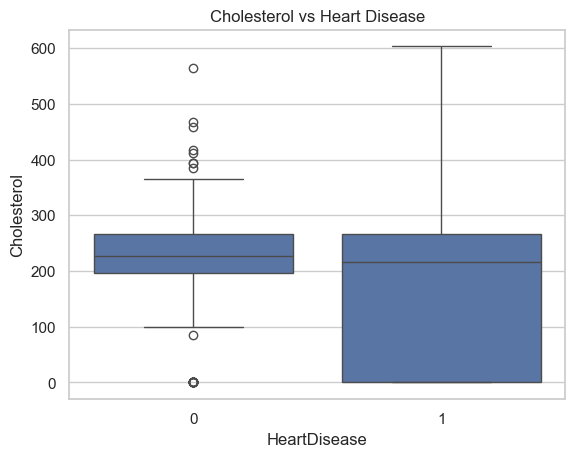

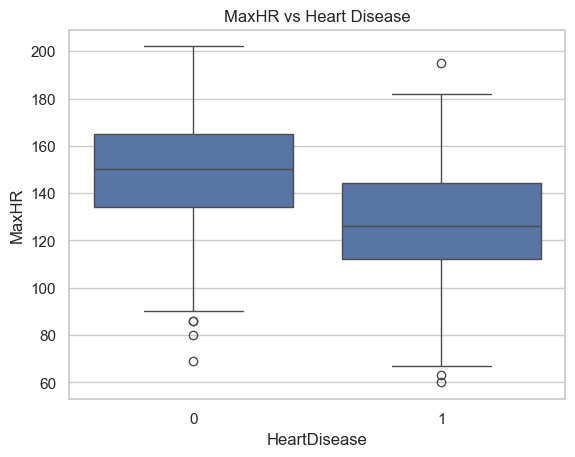

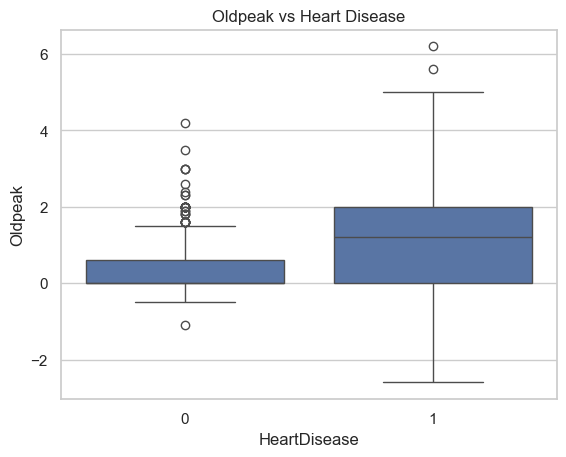

In [59]:
numerical = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]

for col in numerical:
    sns.boxplot(x=target, y=col, data=df)
    plt.title(f"{col} vs Heart Disease")
    plt.show()

## 6.1 Pearson Correlation Matrix

A heatmap of Pearson correlation coefficients among numerical features and the target variable reveals:

- **Strongest predictors**:
  - `Oldpeak` (r ≈ +0.43): Positive correlation with `HeartDisease`
  - `MaxHR` (r ≈ −0.40): Negative correlation with `HeartDisease`
- **Moderate predictors**:
  - `Age` (r ≈ +0.25), `FastingBS` (r ≈ +0.20)
- **Weak predictors**:
  - `RestingBP` (r ≈ +0.08), `Cholesterol` (r ≈ +0.05)

### 6.2 Multicollinearity Assessment

Inter-feature correlations among predictors are generally low (|r| < 0.3), indicating minimal multicollinearity. This supports the inclusion of all numerical features in linear models without substantial risk of coefficient instability. Notable exceptions:
- `Age` and `MaxHR` exhibit a modest negative correlation (r ≈ −0.28), consistent with physiological expectations.

No feature pairs exceed the conventional multicollinearity threshold (|r| > 0.7), obviating the need for dimensionality reduction at this stage.

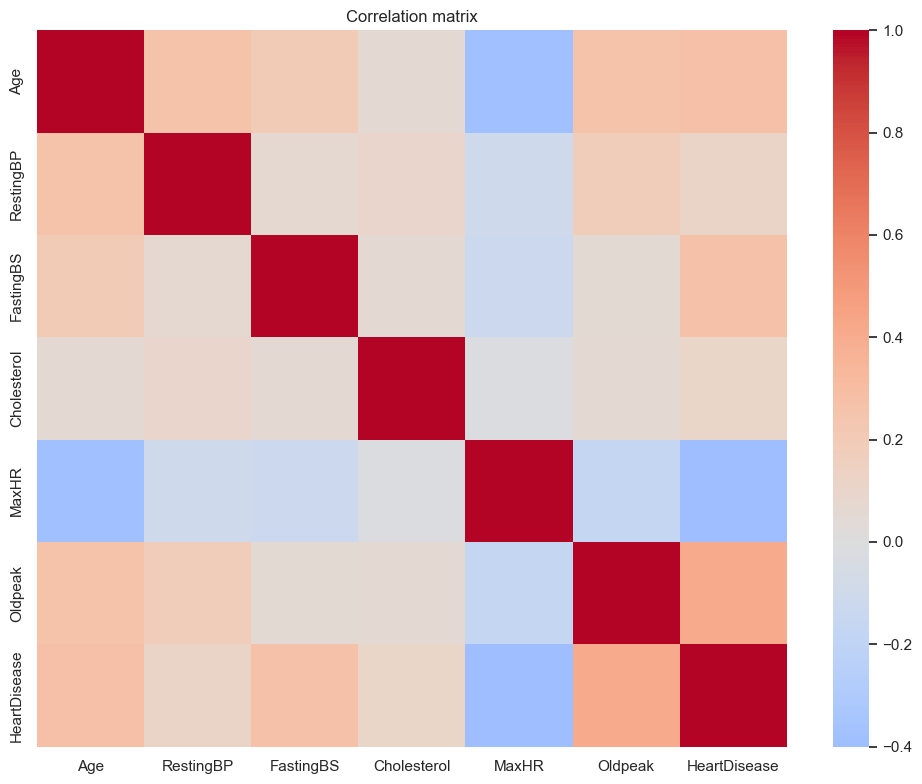

In [60]:

num_cols = ['Age', 'RestingBP', 'FastingBS' , 'Cholesterol', 'MaxHR', 'Oldpeak']


corr = df_eda[num_cols + [target]].corr(numeric_only=True)


plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation matrix')
plt.tight_layout()
plt.show()

## 7.1 Interquartile Range (IQR) Method

Outliers were identified using the Tukey fence method (1.5 × IQR beyond Q1/Q3). The proportion of outliers per numerical feature:

| Feature | Outlier Proportion | Interpretation |
|---------|-------------------|----------------|
| `Cholesterol` | 3.08% | Mild outlier presence; likely physiological extremes |
| `RestingBP` | 2.94% | Consistent with measurement variability |
| `Oldpeak` | 1.74% | Expected given right-skewed distribution |
| `MaxHR` | 0.22% | Negligible; distribution well-behaved |
| `Age`, `FastingBS` | 0.00% | No outliers detected |

### 7.2 Recommendations

Given the low outlier proportions (<3.1% across all features) and the clinical plausibility of extreme values, we recommend:
1. Retaining outliers for initial modeling to preserve signal.
2. Considering robust scaling (e.g., `RobustScaler`) for algorithms sensitive to extreme values.
3. Re-evaluating outlier treatment after baseline model performance assessment.

In [61]:
def iqr_outlier_share(series):
    s = series.dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1

    if iqr == 0:
        return 0

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return ((s < lower) | (s > upper)).mean()

outliers = pd.Series({col: iqr_outlier_share(df_eda[col]) for col in num_cols})
print("\nOutlier share:\n", outliers.sort_values(ascending=False))


Outlier share:
 Cholesterol    0.030831
RestingBP      0.029444
Oldpeak        0.017429
MaxHR          0.002179
Age            0.000000
FastingBS      0.000000
dtype: float64


### 8.1 Preprocessing Pipeline Suggestions

Based on EDA findings, the following preprocessing steps are recommended prior to modeling:

1. **Missing Value Imputation**:
   - `Cholesterol`, `RestingBP`: Median imputation (robust to skew) or model-based imputation.

2. **Encoding**:
   - One-hot encoding for nominal categorical variables (`ChestPainType`, `RestingECG`, `ST_Slope`).
   - Label encoding for binary variables (`Sex`, `ExerciseAngina`, `FastingBS`).

3. **Scaling**:
   - Standardization (`StandardScaler`) for `Age`, `MaxHR`, `Oldpeak`.
   - Robust scaling (`RobustScaler`) for `Cholesterol`, `RestingBP` due to skew/outliers.

4. **Feature Transformations**:
   - Log-transformation for `Cholesterol` and `Oldpeak` to mitigate right skew.
   - Binning `Age` into clinically meaningful groups (e.g., <45, 45–60, 60–75, >75) for interpretability.

5. **Interaction Features** (optional, for tree-based models):
   - `MaxHR × Oldpeak`: Captures combined hemodynamic stress.
   - `Age × ChestPainType`: Age-stratified risk by symptom profile.

### 8.2 Feature Selection Priorities

High-priority features for initial modeling (based on bivariate strength and clinical relevance):
1. `Oldpeak`, `MaxHR`, `ChestPainType`, `ExerciseAngina`, `ST_Slope`
2. Secondary: `Age`, `FastingBS`, `Sex`
3. Lower priority (pending model-based selection): `RestingBP`, `Cholesterol`, `RestingECG`


### 9.1 Key Findings

1. **Data Quality**: The dataset is well-structured with minimal missingness (<19% for the most affected variable) and no duplicates. Recoding of zero-values in `RestingBP` and `Cholesterol` improved data fidelity.

2. **Predictive Signals**:
   - Strongest univariate predictors: `Oldpeak` (positive), `MaxHR` (negative), `ChestPainType` (ASY highest risk).
   - Categorical features (`ExerciseAngina`, `ST_Slope`) exhibit clear stratification of risk.

3. **Modeling Readiness**:
   - Low multicollinearity supports inclusion of all numerical features.
   - Near-balanced target distribution facilitates standard classification metrics.
   - Low outlier proportions suggest minimal need for aggressive outlier treatment.

### 9.2 Recommended Next Steps

1. Implement the preprocessing pipeline outlined in Section 8.1.
2. Train baseline models (logistic regression, random forest) using high-priority features.
3. Evaluate model performance using cross-validated ROC-AUC and calibration metrics.
4. Conduct feature importance analysis to refine the predictor set.
5. Explore calibration and threshold optimization for clinical deployment considerations.

This EDA establishes a solid foundation for developing an interpretable and performant heart disease prediction model.
